Saving LoanPrediction.csv to LoanPrediction.csv
Dataset:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Female,No,3+,Graduate,No,3790,6359,253,300,1,Urban,Y
1,Female,Yes,2,Not Graduate,No,2544,4783,132,360,0,Rural,N
2,Male,Yes,1,Graduate,No,6555,6837,104,180,1,Rural,Y
3,Female,No,2,Not Graduate,No,15030,8719,336,240,1,Urban,Y
4,Female,No,0,Not Graduate,No,15119,8200,132,240,1,Urban,Y



Bank Loan Prediction Accuracy: 0.95

Confusion Matrix:
[[ 8  2]
 [ 3 87]]


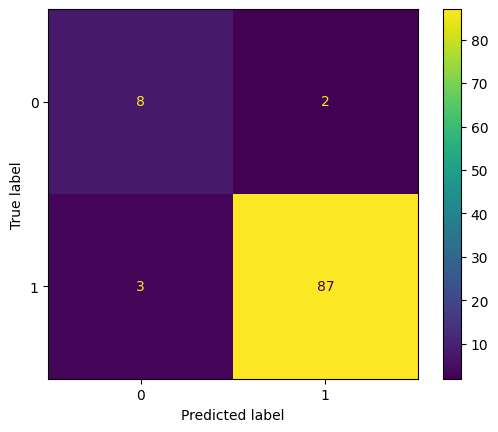

In [1]:
# EXPERIMENT 19: BANK LOAN PREDICTION USING NAIVE BAYES

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Upload CSV
uploaded = files.upload()

# Read CSV
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset:")
display(df.head())

# Encode categorical columns
for column in df.select_dtypes(include="object").columns:

    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])

# Features and target
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Naive Bayes
model = GaussianNB()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nBank Loan Prediction Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()